#Forward Propagation

## Import libraries



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

## Define activation functions


In [ ]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def softmax(z):
    # Numerically stable softmax
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


## Load & Prepare Wine Dataset

Dataset properties:
- 178 samples
- 13 input features per sample
- 3 output classes

X - input features  
y - class labels

This dataset is used only to demonstrate how forward propagation works on real data.






In [ ]:
wine = load_wine()

X = wine.data        # shape: (178, 13)
y = wine.target      # 3 classes: 0,1,2

print("Input shape:", X.shape)
print("Target shape:", y.shape)


Input shape: (178, 13)
Target shape: (178,)


### Standardize features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train–Test Split

We split the dataset into training and test sets to follow a proper machine learning pipeline.

Even though we are currently only performing forward propagation,
we split early so that the same pipeline can be reused later for:

- Loss computation
- Backpropagation
- Model evaluation

At this stage, we will use only the training set.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples     :", X_test.shape[0])


Training samples: 142
Test samples     : 36



## Neural Network Architecture

We use:

- Input Layer: 13 neurons (13 wine features)
- Hidden Layer: 8 neurons
- Output Layer: 3 neurons (multi-class)

In [ ]:
input_neurons = 13
hidden_neurons = 8
output_neurons = 3

print("Network Architecture")
print(f"Input  : {input_neurons}")
print(f"Hidden : {hidden_neurons}")
print(f"Output : {output_neurons}")


Network Architecture
Input  : 13
Hidden : 8
Output : 3


## Initialize weights and biases

Weights and biases are the learnable parameters of a neural network.

Since we are not training yet, we initialize:
- Weights - random values
- Biases - zeros

In [ ]:
# Initialize weights and biases
weights_input_hidden = np.random.randn(input_neurons, hidden_neurons)
biases_hidden = np.zeros((1, hidden_neurons))

weights_hidden_output = np.random.randn(hidden_neurons, output_neurons)
biases_output = np.zeros((1, output_neurons))

# Print shapes to verify
print("Shape of weights_input_hidden:", weights_input_hidden.shape)
print("Shape of biases_hidden:", biases_hidden.shape)
print("Shape of weights_hidden_output:", weights_hidden_output.shape)
print("Shape of biases_output:", biases_output.shape)

Shape of weights_input_hidden: (13, 8)
Shape of biases_hidden: (1, 8)
Shape of weights_hidden_output: (8, 3)
Shape of biases_output: (1, 3)


## Implement forward propagation

This function performs forward propagation — computing the network output for a given input.

Steps performed:

1. Hidden layer linear computation → X·W₁ + b₁
2. Apply ReLU activation
3. Output layer linear computation → a₁·W₂ + b₂
4. Apply Softmax activation → class probabilities

In [ ]:
def forward_propagation(X, W1, b1, W2, b2):
    # Hidden layer
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)

    # Output layer
    z2 = np.dot(a1, W2) + b2
    a2 = softmax(z2)   # element-wise, for demo

    return z1, a1, z2, a2

## Run Forward Propogation on one wine sample

In [ ]:
sample_index = 0
sample_input = X_train[sample_index].reshape(1, -1)

z1, a1, z2, output = forward_propagation(
    sample_input,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)

print("\nHidden Layer Output (Before ReLU):")
print(z1)

print("\nHidden Layer Output (After ReLU):")
print(a1)

print("\nOutput Layer (After Softmax):")
print(output)
print("Sum of probabilities:", np.sum(output))



Hidden Layer Output (Before ReLU):
[[-2.9339041  -6.64570911  1.27825022 -3.9429761  -2.08265344 -2.7093968
  -2.85962391  2.46779867]]

Hidden Layer Output (After ReLU):
[[0.         0.         1.27825022 0.         0.         0.
  0.         2.46779867]]

Output Layer (After Softmax):
[[0.72531551 0.24439165 0.03029284]]
Sum of probabilities: 1.0


In [ ]:
predicted_class = np.argmax(output)
true_class = y_train[sample_index]

print("\nPredicted Class:", predicted_class)
print("True Class     :", true_class)


Predicted Class: 0
True Class     : 0


## Visualization: Actual vs Predicted Classes

We use a scatter plot to compare:

- True class labels
- Predicted class labels from an untrained network

This plot is NOT an evaluation metric.



In [ ]:
num_samples = X_train.shape[0]
actual_classes = y_train

# Run forward propagation for all training samples to get predicted classes
_, _, _, probabilities = forward_propagation(
    X_train,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)
predicted_classes = np.argmax(probabilities, axis=1)

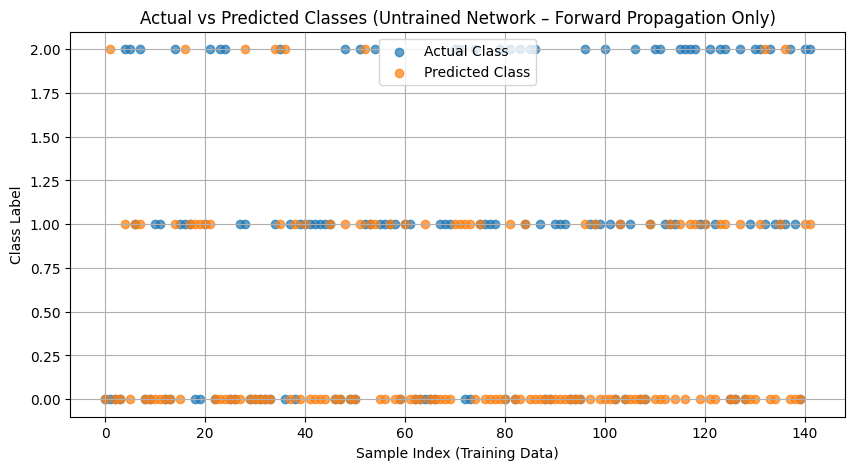

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(range(num_samples), actual_classes,
            label="Actual Class", alpha=0.7)

plt.scatter(range(num_samples), predicted_classes,
            label="Predicted Class", alpha=0.7)

plt.xlabel("Sample Index (Training Data)")
plt.ylabel("Class Label")
plt.title("Actual vs Predicted Classes (Untrained Network – Forward Propagation Only)")
plt.legend()
plt.grid(True)

plt.show()

This plot illustrates how an untrained neural network behaves during forward propagation.
The predicted classes (orange) often differ from the actual classes (blue) because the weights are randomly initialized and no learning has occurred yet.

It highlights that forward propagation can generate predictions, but model learning and improvement require a loss function and backpropagation.

## Accuracy

In [ ]:
accuracy = np.mean(np.array(predicted_classes) == np.array(actual_classes))
print("Training accuracy (random weights):", accuracy)

Training accuracy (random weights): 0.3873239436619718


## Conclusion

Forward propagation:

- Takes input features
- Applies weights and biases
- Uses activation functions
- Produces class probabilities
- Generates predictions

However, the network does not yet know whether predictions are correct.

Next steps in neural network learning:
- Define a loss function
- Measure prediction error
- Use backpropagation to update weights


## Forward Propagation on All Training Samples

We run forward propagation across all training samples and collect:

- Actual class labels
- Predicted class labels

Since the network is untrained and weights are random,
predictions will not align well with actual labels — this is expected.


#Back Propogation

## Define the Loss Function

We use Categorical Cross entropy for this problem

Cross-entropy loss measures how different the predicted probability distribution is from the true class distribution.


### One-Hot Encoding of Labels

Cross-entropy loss compares probability vectors with true class vectors.

We convert class labels into one-hot vectors so they match the softmax output shape.

Example:
Class 2 → [0, 0, 1]


In [ ]:
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot


y_train_one_hot = one_hot_encode(y_train, output_neurons)

print("One-hot label shape:", y_train_one_hot.shape)
print("Example label:", y_train[0])
print("One-hot encoded:", y_train_one_hot[0])


One-hot label shape: (142, 3)
Example label: 0
One-hot encoded: [1. 0. 0.]


###Cross-Entropy Loss Function

In [ ]:
def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-9
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.sum(y_true * np.log(y_pred), axis=1)
    return np.mean(loss)

## Loss on One Sample

We compute cross-entropy loss for a single sample to verify that our loss function works correctly before batch training.


In [ ]:
# True label (one-hot)
y_true_sample = y_train_one_hot[sample_index].reshape(1, -1)

# Predicted probabilities from forward pass
y_pred_sample = output

loss_sample = cross_entropy_loss(y_true_sample, y_pred_sample)

print("Loss for single sample:", loss_sample)


Loss for single sample: 0.32114853934804316


## Backpropagation

Backpropagation computes gradients of the loss with respect to weights and biases.

We propagate error backward through layers using the chain rule:

Output layer → hidden layer → parameters

These gradients tell us how each parameter should change to reduce loss.


In [ ]:
def backward_propagation(X, y_true, z1, a1, z2, a2, W2):
    m = X.shape[0]  # batch size

    #Output layer gradients
    dz2 = (a2 - y_true) / m

    dW2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    #Hidden layer gradients
    da1 = np.dot(dz2, W2.T)

    dz1 = da1.copy()
    dz1[z1 <= 0] = 0   # derivative of ReLU

    dW1 = np.dot(X.T, dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

## Parameter Update (Gradient Descent)

We update weights and biases using gradient descent:

parameter = parameter − learning_rate × gradient

This step reduces loss over iterations.


In [ ]:
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    return W1, b1, W2, b2

## Training Loop

We repeat forward pass → loss → backward pass → parameter update for multiple epochs.

Each epoch adjusts parameters to reduce loss and improve predictions.


In [ ]:
learning_rate = 0.05
epochs = 100
loss_history = []

for epoch in range(epochs):

    # Forward
    z1, a1, z2, a2 = forward_propagation(
        X_train,
        weights_input_hidden,
        biases_hidden,
        weights_hidden_output,
        biases_output
    )

    # Loss
    loss = cross_entropy_loss(y_train_one_hot, a2)
    loss_history.append(loss)


    # Backward
    dW1, db1, dW2, db2 = backward_propagation(
        X_train, y_train_one_hot,
        z1, a1, z2, a2,
        weights_hidden_output
    )

    # Update
    weights_input_hidden, biases_hidden, \
    weights_hidden_output, biases_output = update_parameters(
        weights_input_hidden, biases_hidden,
        weights_hidden_output, biases_output,
        dW1, db1, dW2, db2,
        learning_rate
    )

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss = {loss:.4f}")


Epoch 0 | Loss = 5.2334
Epoch 20 | Loss = 0.6801
Epoch 40 | Loss = 0.4437
Epoch 60 | Loss = 0.3209
Epoch 80 | Loss = 0.2448


###Plot Training Loss Vs Epoch

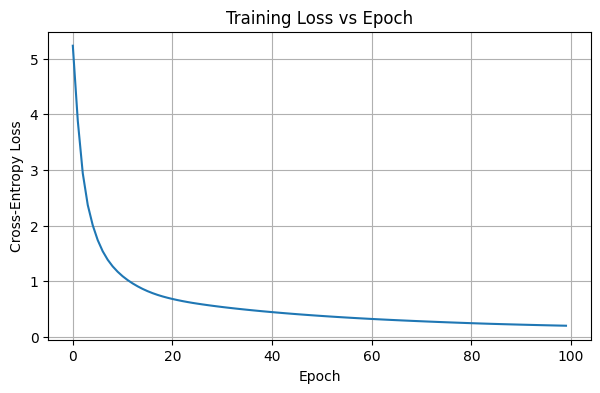

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.show()


## Prediction Function

The prediction function runs forward propagation and selects the class with the highest probability using argmax.


In [ ]:
def predict(X, W1, b1, W2, b2):
    _, _, _, a2 = forward_propagation(X, W1, b1, W2, b2)
    return np.argmax(a2, axis=1)


## Model Evaluation

After training, we compute:

- Training accuracy
- Test accuracy
- Training loss
- Test loss

These metrics measure how well the model has learned and how well it generalizes.


In [ ]:
# Predictions
y_train_pred = predict(
    X_train,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)

y_test_pred = predict(
    X_test,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)

# Accuracy
train_accuracy = np.mean(y_train_pred == y_train)
test_accuracy  = np.mean(y_test_pred == y_test)

print(f"Train Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


Train Accuracy: 93.66%
Test Accuracy : 91.67%


In [ ]:
# One-hot encode test labels
y_test_one_hot = one_hot_encode(y_test, output_neurons)

# Forward passes
_, _, _, a2_train = forward_propagation(
    X_train,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)

_, _, _, a2_test = forward_propagation(
    X_test,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)

train_loss = cross_entropy_loss(y_train_one_hot, a2_train)
test_loss  = cross_entropy_loss(y_test_one_hot, a2_test)

print(f"Train Loss: {train_loss:.4f}")
print(f"Test Loss : {test_loss:.4f}")


Train Loss: 0.1972
Test Loss : 0.2449


In [ ]:
for i in range(5):
    print(
        f"Sample {i} | True: {y_test[i]} | Pred: {y_test_pred[i]}"
    )


Sample 0 | True: 0 | Pred: 0
Sample 1 | True: 2 | Pred: 2
Sample 2 | True: 0 | Pred: 0
Sample 3 | True: 1 | Pred: 1
Sample 4 | True: 1 | Pred: 2


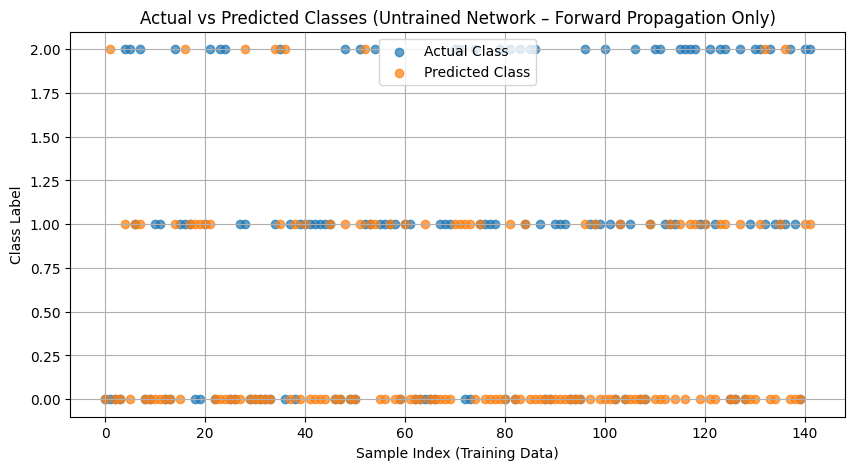

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(range(num_samples), actual_classes,
            label="Actual Class", alpha=0.7)

plt.scatter(range(num_samples), predicted_classes,
            label="Predicted Class", alpha=0.7)

plt.xlabel("Sample Index (Training Data)")
plt.ylabel("Class Label")
plt.title("Actual vs Predicted Classes (Untrained Network – Forward Propagation Only)")
plt.legend()
plt.grid(True)

plt.show()


## Summary

We implemented a neural network from scratch including:

- Forward propagation
- Cross-entropy loss
- Backpropagation
- Gradient descent updates
- Training loop
- Evaluation

This demonstrates the full learning pipeline without using deep learning frameworks.
